# ResNet Core Architecture Notes
**Date:** May 1, 2026
**Paper:** Deep Residual Learning for Image Recognition (Targeted Reading)

## 1. Why Plain Networks Degrade (The Degradation Problem)
Before ResNet, the industry believed depth equaled power. But when pushing past ~30 layers, models broke. 

* **The Reality:** As network depth increases, accuracy gets saturated and then rapidly degrades. 
* **Crucial Distinction:** This is **NOT overfitting**. In overfitting, training error is low and test error is high. In the degradation problem, the **training error itself spikes**. 
* **The Root Cause:** The optimizer (SGD/Backprop) gets completely lost in the high-dimensional space. Mathematically, a deeper network should be able to tie a shallow network's score by simply turning its extra layers into "identity mappings" (doing nothing). But a standard neural network layer (with random weights and ReLUs) is practically incapable of learning the function $f(x) = x$ from scratch. The optimizer twists the data, corrupts the signal, and ruins the training.

## 2. Why the Identity Shortcut Helps (The Bypass Lane)
Instead of hoping the optimizer will magically figure out how to do nothing, ResNet hardwires a "bypass lane" directly into the architecture.

* **The Old Equation (Plain Layer):** 
  $$Output = \mathcal{F}(x)$$
  *(If the layer sucks, the data is permanently corrupted.)*

* **The New Equation (Residual Block):** 
  $$Output = \mathcal{F}(x) + x$$
  *(Where $x$ is the pristine, untouched input from the previous layer, and $\mathcal{F}(x)$ is the meat grinder/transformation).*

* **Why it Hacks the Optimizer:** 
  The optimizer is lazy; it seeks the easiest path to zero loss. By adding $+ x$, we change what the layer has to learn. Instead of learning an entire unreferenced mapping, the layer only has to learn the **residual** (the difference between the input and the ideal output). 
  If the layer is useless, the optimizer simply pushes the weights of $\mathcal{F}(x)$ to $0$. 
  The equation becomes $0 + x = x$. 
  The network has automatically created an identity mapping, effectively "turning off" the useless layer and passing the pristine data forward. Degradation is solved.

## 3. The Block Diagram (Structural Translation)
The fundamental building block consists of two paths:
1. **The Transformation Path:** $x \rightarrow \text{Weight Layer} \rightarrow \text{ReLU} \rightarrow \text{Weight Layer} \rightarrow \mathcal{F}(x)$
2. **The Shortcut Connection:** $x$ skips all the weights entirely.
3. **The Merger:** The two paths are added together $\mathcal{F}(x) + x$ via element-wise addition.
4. **Final Output:** The merged result is passed through a final ReLU activation before moving to the next block.

*Note on Dimensions:* For element-wise addition to work, the physical shape (dimensions) of $\mathcal{F}(x)$ and $x$ MUST be identical. If the network needs to shrink the image, it applies a linear projection (a $1\times1$ convolution) to the shortcut connection $x$ to match the new dimensions.

In [4]:
import matplotlib.pyplot as plt
import json

## GRADIENT FLOW COMPARISON

In [5]:
plain_cnn_grad_data = []
resnet_grad_data = []

with open("./../experiments/plain_cnn_loss_log.json","r") as f:
    plain_cnn_grad_data = json.load(f)
    
    
with open("./../experiments/resnet_loss_log.json","r") as f:
    resnet_grad_data = json.load(f)


['5_fc', '4_Layer3', '3_Layer2', '2_Layer1', '1_conv1']
['5_fc', '4_Layer3', '3_Layer2', '2_Layer1', '1_conv1']


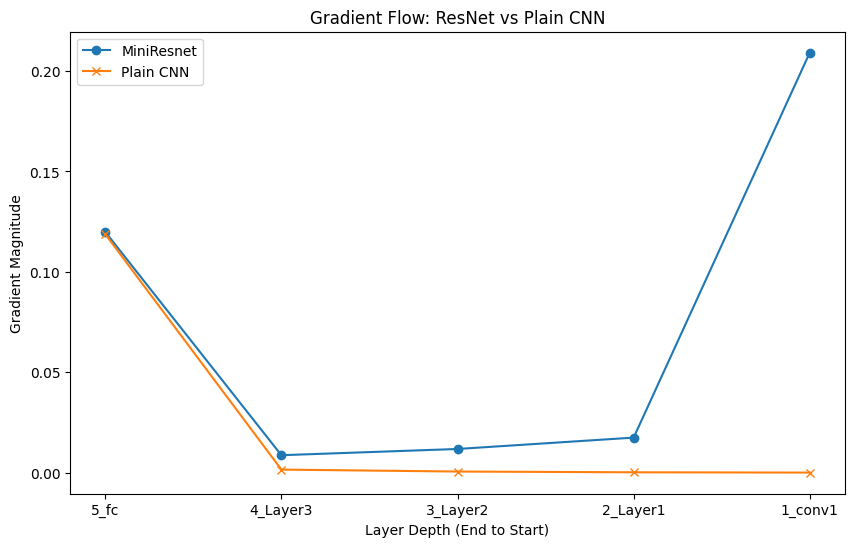

In [6]:
resnet_layers = list(resnet_grad_data[0].keys())
print(resnet_layers)
resnet_magnitude = list(resnet_grad_data[0].values())



plain_layers = list(plain_cnn_grad_data[0].keys())
print(plain_layers)
plain_magnitude = list(plain_cnn_grad_data[0].values())


plt.figure(figsize=(10,6))


plt.plot(resnet_layers,resnet_magnitude,label="MiniResnet",marker='o')
plt.plot(plain_layers,plain_magnitude,label="Plain CNN",marker='x')



plt.title("Gradient Flow: ResNet vs Plain CNN")
plt.xlabel("Layer Depth (End to Start)")
plt.ylabel("Gradient Magnitude")
plt.savefig("./../experiments/gradient_flow_comparion.png")
plt.legend()



